In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, json, shutil
import numpy as np
import matplotlib.pyplot as plt
import itertools
from math import ceil
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

In [ ]:
DRIVE_BASE = "/content/drive/MyDrive/Chest X-Rays"
TRAIN_DIR = os.path.join(DRIVE_BASE, "train")
VALID_DIR = os.path.join(DRIVE_BASE, "test")
MODEL_NAME = "chest_pneumonia_model"
OUT_DIR = f"/content/{MODEL_NAME}"

IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 8
LEARNING_RATE = 1e-4
NUM_CLASSES = 1
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

train_aug = ImageDataGenerator(
    preprocessing_function=eff_preprocess,
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    shear_range=0.05,
    zoom_range=0.08,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_aug = ImageDataGenerator(preprocessing_function=eff_preprocess)

train_gen = train_aug.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

valid_gen = valid_aug.flow_from_directory(
    VALID_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

index_to_label = {v: k for k, v in train_gen.class_indices.items()}
class_labels = [index_to_label[i] for i in range(len(index_to_label))]
print("Detected class labels (index->label):", index_to_label)

Found 5232 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Detected class labels (index->label): {0: 'NORMAL', 1: 'PNEUMONIA'}


In [ ]:
inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name="input_image")
base = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inputs)

for layer in base.layers:
    layer.trainable = False

for layer in base.layers[-20:]:
    layer.trainable = True

x = base.output
x = GlobalAveragePooling2D(name="gap")(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation="sigmoid", name="predictions")(x)

model = Model(inputs=inputs, outputs=outputs, name="efficientnetb0_chest")
model.compile(optimizer=Adam(LEARNING_RATE), loss="binary_crossentropy", metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])

steps_per_epoch = ceil(train_gen.samples / train_gen.batch_size)
validation_steps = ceil(valid_gen.samples / valid_gen.batch_size)

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=valid_gen,
    validation_steps=validation_steps,
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 1348s 4s/step - accuracy: 0.8728 - auc: 0.9320 - loss: 0.3246 - val_accuracy: 0.9263 - val_auc: 0.9877 - val_loss: 0.1883
Epoch 2/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 589s 2s/step - accuracy: 0.9546 - auc: 0.9907 - loss: 0.1187 - val_accuracy: 0.9503 - val_auc: 0.9912 - val_loss: 0.1416
Epoch 3/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 593s 2s/step - accuracy: 0.9624 - auc: 0.9931 - loss: 0.0979 - val_accuracy: 0.9599 - val_auc: 0.9916 - val_loss: 0.1217
Epoch 4/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 593s 2s/step - accuracy: 0.9695 - auc: 0.9958 - loss: 0.0754 - val_accuracy: 0.9295 - val_auc: 0.9921 - val_loss: 0.1626
Epoch 5/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 630s 2s/step - accuracy: 0.9766 - auc: 0.9972 - loss: 0.0610 - val_accuracy: 0.9119 - val_auc: 0.9875 - val_loss: 0.2219
Epoch 6/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 597s 2s/step - accuracy: 0.9730 - auc: 0.9965 - loss: 0.0669 - val_accuracy: 0.9151 - val_auc: 0.9817 - val_loss: 0.2388
Epoch 7/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
def generator_predict_and_labels(model, generator):
    """Predict across a generator and collect y_true, y_prob, y_pred."""
    steps = ceil(generator.samples / generator.batch_size)
    preds = model.predict(generator, steps=steps, verbose=1)
    if preds.ndim == 2 and preds.shape[1] == 1:
        y_score = preds.flatten()
    else:
        y_score = preds 
    y_true = generator.classes
    return np.array(y_true), np.array(y_score)

y_true, y_score = generator_predict_and_labels(model, valid_gen)

if y_score.ndim == 1:
    y_pred = (y_score >= 0.5).astype(int)
else:
    y_pred = np.argmax(y_score, axis=1)

39/39 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step


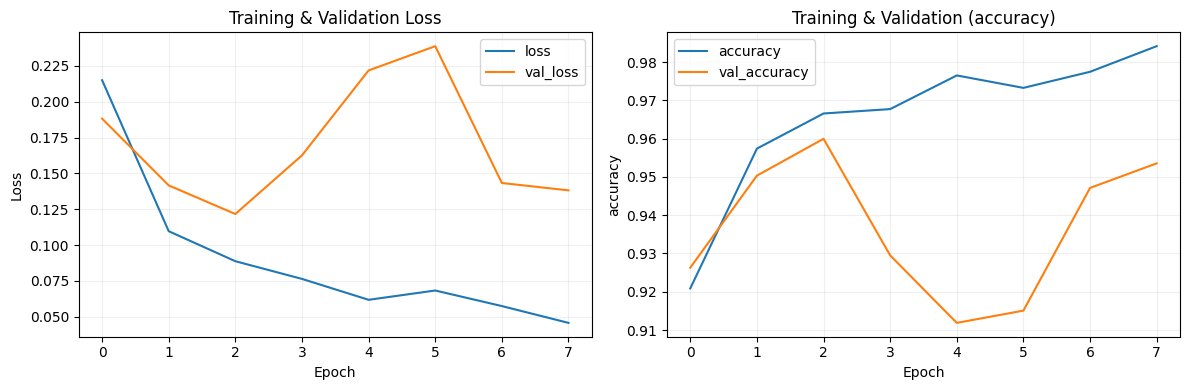

In [ ]:
hist = history.history 

loss_key = "loss"
val_loss_key = "val_loss" if "val_loss" in hist else None

metric_key = 'accuracy'

plt.figure(figsize=(12,4))

# Loss plot
plt.subplot(1,2,1)
plt.plot(hist.get("loss", []), label="loss")
if val_loss_key:
    plt.plot(hist.get("val_loss", []), label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(alpha=0.2)

# Metric plot
plt.subplot(1,2,2)
if metric_key:
    plt.plot(hist.get(metric_key, []), label=metric_key)
    val_metric = "val_" + metric_key if "val_" + metric_key in hist else None
    if val_metric:
        plt.plot(hist.get(val_metric, []), label=val_metric)
    plt.xlabel("Epoch")
    plt.ylabel(metric_key)
    plt.title(f"Training & Validation ({metric_key})")
    plt.legend()
    plt.grid(alpha=0.2)
else:
    plt.text(0.5, 0.5, "No metric found in history", ha="center")

plt.tight_layout()
plt.show()


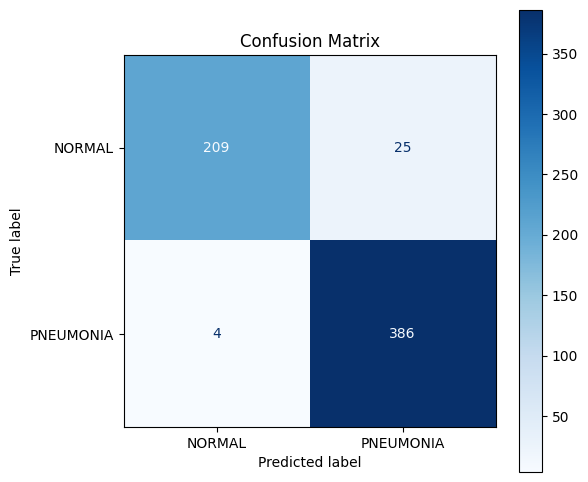

In [ ]:
cm = confusion_matrix(y_true, y_pred)
labels = valid_gen.class_indices
index_to_label = {v:k for k,v in valid_gen.class_indices.items()}
label_names = [index_to_label[i] for i in range(len(index_to_label))]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print("Classification Report (by class):")
print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

Classification Report (by class):
              precision    recall  f1-score   support

      NORMAL     0.9812    0.8932    0.9351       234
   PNEUMONIA     0.9392    0.9897    0.9638       390

    accuracy                         0.9535       624
   macro avg     0.9602    0.9415    0.9495       624
weighted avg     0.9549    0.9535    0.9530       624



In [ ]:
keras_file = os.path.join(OUT_DIR, f"{MODEL_NAME}.keras")
model.save(keras_file, include_optimizer=False)
print("Saved Keras-native file:", keras_file)

serving_dir = os.path.join(OUT_DIR, "exported_for_serving")
if hasattr(model, "export"):
    try:
        model.export(serving_dir)
        print("Saved serving export via model.export to:", serving_dir)
    except Exception as e:
        print("model.export failed, falling back to tf.saved_model.save:", e)
        tf.saved_model.save(model, serving_dir)
else:
    tf.saved_model.save(model, serving_dir)
    print("Saved serving via tf.saved_model.save to:", serving_dir)

meta = {
    "input_size": [IMAGE_SIZE, IMAGE_SIZE],
    "preprocessing": "efficientnet_preprocess",
    "class_labels": class_labels,
    "last_conv_layer": "top_conv"
}

with open(os.path.join(OUT_DIR, "meta.json"), "w") as f:
    json.dump(meta, f)
with open(os.path.join(OUT_DIR, "index_to_label.json"), "w") as f:
    json.dump(index_to_label, f)

shutil.make_archive(OUT_DIR + "_bundle", 'zip', OUT_DIR)
print("Zipped bundle to:", OUT_DIR + "_bundle.zip")

Saved Keras-native file: /content/chest_pneumonia_model/chest_pneumonia_model.keras
Saved artifact at '/content/chest_pneumonia_model/exported_for_serving'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139600225092432: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139600225092240: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  139600229565648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139600229565456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139600229564688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139602600875152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139600253451536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139600229566992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139600229568720: T